Model architecture একদম same — C7 + SupCon λ=0.2, τ=0.05।
শুধু train time এ N1 epoch গুলোতে 4টা augmentation randomly apply হবে:
Augmentationকী করেকেন N1 এ help করবেGaussian noiseসামান্য noise যোগsensor noise robustnessTime shift±50 sample shiftboundary ambiguity handleAmplitude scale0.8x-1.2xsubject variabilityChannel swapL↔R EEG swapbilateral symmetry
Test set এ কোনো augmentation নেই — clean inference।

Model Architecture
------------------
• Architecture একই থাকবে : C7 + SupCon
• λ = 0.2
• τ = 0.05

Training Phase (প্রথম N1 epoch)
-------------------------------
• প্রথম N1 epoch এ ৪টি augmentation random ভাবে apply করা হবে।

1. Gaussian Noise
• Signal এ সামান্য random noise যোগ করা হয়।
• Sensor noise এর প্রতি model কে robust করতে সাহায্য করে।

2. Time Shift
• Signal কে ±50 sample shift করা হয়।
• Boundary ambiguity এবং timing variation handle করতে সাহায্য করে।

3. Amplitude Scale
• Signal amplitude 0.8× – 1.2× scale করা হয়।
• বিভিন্ন subject এর signal variation মোকাবেলায় সাহায্য করে।

4. Channel Swap
• Left ও Right EEG channel (L ↔ R) interchange করা হয়।
• Brain এর bilateral symmetry কাজে লাগাতে সাহায্য করে।

Testing Phase
-------------
• Test set এ কোনো augmentation apply করা হয় না।
• Clean signal এর উপর inference করা হয়।

Summary
-------
• C7 + SupCon architecture অপরিবর্তিত থাকে।
• শুধুমাত্র প্রথম N1 epoch এ random augmentation ব্যবহার করা হয়।
• Gaussian Noise → sensor noise robustness।
• Time Shift → boundary ambiguity handle।
• Amplitude Scale → subject variability handle।
• Channel Swap → bilateral symmetry exploit।
• Test time এ clean inference করা হয়।

Device        : cuda
Seeds         : [42, 123, 256, 789, 999]
Context       : 7 (window=15)
SupCon λ=0.2, τ=0.05
N1 Aug prob   : 0.5 per transform
Output        : D:\22\AA\evaluation\supcon_c7_n1aug_artifact-aware
Split loaded -> Train:76  Test:20
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Building datasets (once for all seeds)...
  Samples  : 71,347  [WITH N1 augmentation]
  RAM      : 2.57 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  59,303 (83.1%)
    w=0.4 :     930 (1.3%)
    w=0.2 :   7,686 (10.8%)
    w=0.1 :   3,385 (4.7%)
    w=0.0 :      43 (0.1%)

  Samples  : 19,763  [NO augmentation]
  RAM      : 0.71 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  15,258 (77.2%)
    w=0.4 :     428 (2.2%)
    w=0.2 :   3,306 (16.7%)
    w=0.1 :     771 (3.9%)
Datasets r

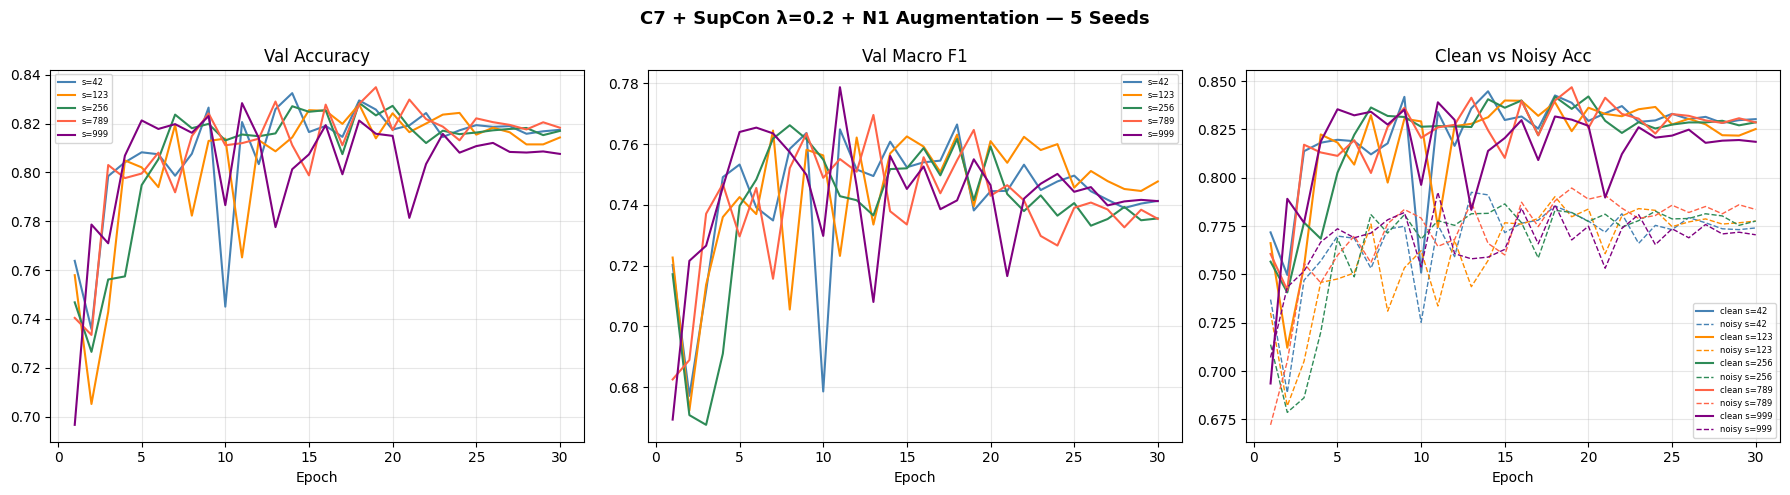

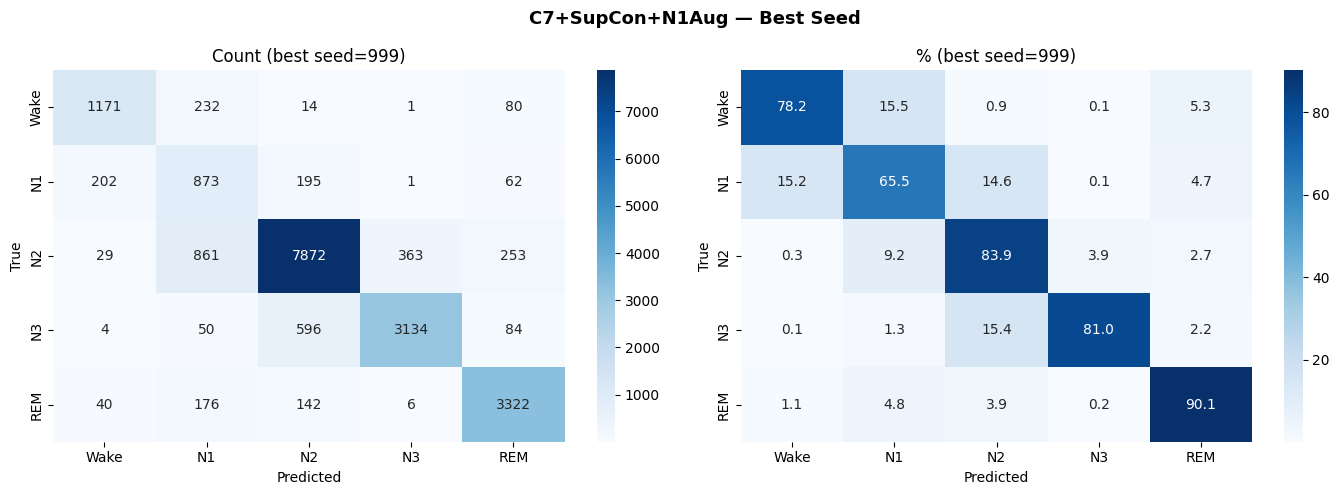

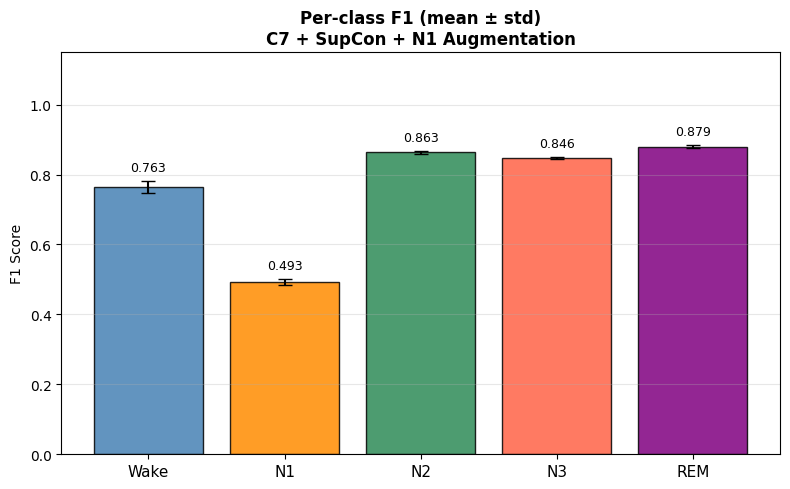


All outputs saved: D:\22\AA\evaluation\supcon_c7_n1aug_artifact-aware
Done!


In [2]:
# ============================================================
# Context=7 + SupCon (λ=0.2, τ=0.05) + N1 Augmentation
#
# Previous best: C7 + SupCon λ=0.2 → Acc=82.31%, F1=0.7772, N1=0.5146
#
# What's new:
#   N1 minority class augmentation during training:
#     1. Gaussian noise    (σ=0.05)
#     2. Time shift        (±50 samples max)
#     3. Amplitude scale   (0.8x ~ 1.2x)
#     4. Channel swap      (EEG ch0 ↔ ch1)
#   → Only N1 epochs get augmented (label=1)
#   → Applied randomly per batch, p=0.5 each
#   → Test set: NO augmentation (clean inference)
#
# Everything else same as best model:
#   CONTEXT=7, WINDOW=15, D_MODEL=128, NHEAD=8
#   NUM_LAYERS=3, BATCH=64, N_EPOCHS=50
#   AdamW + warmup cosine, artifact weighting
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS & CONFIG
# ============================================================
SAVE_PATH     = r"D:\22\AA\preprocess\preprocessed_FFinal"
ARTIFACT_PATH = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"
EVAL_PATH     = r"D:\22\AA\evaluation\supcon_c7_n1aug_artifact-aware"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES   = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT       = 7
WINDOW        = 2 * CONTEXT + 1    # 15
N_EPOCHS      = 30
BATCH_SIZE    = 64
SEEDS         = [42, 123, 256, 789, 999]

# SupCon (same as best)
SUPCON_LAMBDA = 0.2
SUPCON_TEMP   = 0.05
PROJ_DIM      = 64

# N1 Augmentation config
AUG_PROB      = 0.5    # probability of applying each augmentation
AUG_NOISE_STD = 0.05   # Gaussian noise std
AUG_SHIFT_MAX = 50     # max time shift in samples (out of 3000)
AUG_SCALE_MIN = 0.8    # amplitude scale min
AUG_SCALE_MAX = 1.2    # amplitude scale max

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"Seeds         : {SEEDS}")
print(f"Context       : {CONTEXT} (window={WINDOW})")
print(f"SupCon λ={SUPCON_LAMBDA}, τ={SUPCON_TEMP}")
print(f"N1 Aug prob   : {AUG_PROB} per transform")
print(f"Output        : {EVAL_PATH}")

# ============================================================
# ARTIFACT WEIGHT CONFIG
# ============================================================
ARTIFACT_WEIGHT_MAP = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_CHANNELS     = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_CHANNELS   = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]


# ============================================================
# ARTIFACT WEIGHT LOADER
# ============================================================
def load_artifact_weights(subject_id, artifact_path, epoch_duration=30):
    tsv_path = os.path.join(
        artifact_path, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return None
    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return None

    available = [ch for ch in TARGET_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_CHANNELS if ch in df.columns]
    if not available:
        return None

    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // epoch_duration).astype(int)
    epoch_scores = df.groupby('sleep_epoch')['worst_score'].max()

    n_ep    = int(epoch_scores.index.max()) + 1
    weights = np.ones(n_ep, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        weights[int(ep_idx)] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)
    return weights


# ============================================================
# FIXED SPLIT
# ============================================================
all_subjects = sorted([
    f.replace(".npz", "")
    for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])

_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

if os.path.exists(_train_path) and os.path.exists(_test_path):
    TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
    TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
    print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")
else:
    _subs = all_subjects.copy()
    random.seed(42)
    random.shuffle(_subs)
    n          = int(0.8 * len(_subs))
    TRAIN_SUBS = _subs[:n]
    TEST_SUBS  = _subs[n:]
    np.save(_train_path, np.array(TRAIN_SUBS))
    np.save(_test_path,  np.array(TEST_SUBS))
    print(f"Split created -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print(f"TEST_SUBS: {TEST_SUBS}")


# ============================================================
# N1 AUGMENTATION FUNCTIONS
# Applied only to N1 epochs during training
# ============================================================
def aug_gaussian_noise(signal, std=AUG_NOISE_STD):
    """Add small Gaussian noise — simulates sensor noise"""
    return signal + np.random.randn(*signal.shape).astype(np.float32) * std


def aug_time_shift(signal, max_shift=AUG_SHIFT_MAX):
    """Shift signal in time — N1 boundary ambiguity"""
    shift = np.random.randint(-max_shift, max_shift)
    return np.roll(signal, shift, axis=-1)  # shift along time axis


def aug_amplitude_scale(signal, min_s=AUG_SCALE_MIN, max_s=AUG_SCALE_MAX):
    """Scale amplitude randomly — inter-subject variability"""
    scale = np.random.uniform(min_s, max_s)
    return signal * scale


def aug_channel_swap(signal):
    """Swap EEG ch0 ↔ ch1 — left/right hemisphere symmetry"""
    signal = signal.copy()
    signal[[0, 1], :] = signal[[1, 0], :]
    return signal


def augment_n1_epoch(epoch):
    """
    epoch: (C, T) numpy array — single 30s epoch
    Apply each augmentation independently with probability AUG_PROB
    """
    if random.random() < AUG_PROB:
        epoch = aug_gaussian_noise(epoch)
    if random.random() < AUG_PROB:
        epoch = aug_time_shift(epoch)
    if random.random() < AUG_PROB:
        epoch = aug_amplitude_scale(epoch)
    if random.random() < AUG_PROB:
        epoch = aug_channel_swap(epoch)
    return epoch


# ============================================================
# DATASET — with N1 augmentation flag
# ============================================================
class ArtifactAwareDataset(Dataset):
    def __init__(self, subject_list, data_path,
                 artifact_path, context=CONTEXT,
                 augment_n1=False):
        """
        augment_n1: True for train set, False for test set
        """
        self.context    = context
        self.augment_n1 = augment_n1
        self.data       = []
        self.index      = []

        label_counter  = Counter()
        weight_counter = Counter()
        no_tsv_count   = 0

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],    :]
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d['labels'].copy()

            n     = len(labels)
            art_w = load_artifact_weights(sub, artifact_path)
            if art_w is None:
                art_w        = np.ones(n, dtype=np.float32)
                no_tsv_count += 1
            else:
                if len(art_w) >= n:
                    art_w = art_w[:n]
                else:
                    pad   = np.ones(n - len(art_w), dtype=np.float32)
                    art_w = np.concatenate([art_w, pad])

            sub_idx = len(self.data)
            self.data.append((signal, labels))

            for i in range(n):
                w = float(art_w[i])
                self.index.append((sub_idx, i, n, w))
                label_counter[int(labels[i])] += 1
                weight_counter[round(w, 1)]   += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(5)], dtype=np.float32
        )

        total = len(self.index)
        ram   = sum(s.nbytes for s, _ in self.data) / 1e9
        aug_str = "WITH N1 augmentation" if augment_n1 else "NO augmentation"
        print(f"  Samples  : {total:,}  [{aug_str}]")
        print(f"  RAM      : {ram:.2f} GB")
        print(f"  No TSV   : {no_tsv_count} subjects")
        print(f"  Weight distribution:")
        for w in sorted(weight_counter.keys(), reverse=True):
            pct = weight_counter[w] / total * 100
            print(f"    w={w:.1f} : {weight_counter[w]:>7,} ({pct:.1f}%)")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels = self.data[sub_idx]
        label = int(labels[center_i])

        # Build context window
        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei  = max(0, min(n - 1, center_i + offset))
            ep  = signal[ei].copy()   # (C, T)

            # Apply N1 augmentation only on center epoch during training
            if self.augment_n1 and label == 1 and offset == 0:
                ep = augment_n1_epoch(ep)

            window_epochs.append(ep)

        x = np.stack(window_epochs, axis=0)   # (W, C, T)
        return (
            torch.FloatTensor(x),
            torch.tensor(label, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32)
        )


# ============================================================
# BUILD DATASETS
# ============================================================
print("\nBuilding datasets (once for all seeds)...")
train_ds = ArtifactAwareDataset(
    TRAIN_SUBS, SAVE_PATH, ARTIFACT_PATH, augment_n1=True
)
print()
test_ds  = ArtifactAwareDataset(
    TEST_SUBS, SAVE_PATH, ARTIFACT_PATH, augment_n1=False
)
print("Datasets ready.")

# N1 count in train
n1_count   = int(train_ds.label_counts[1])
total_count = int(train_ds.label_counts.sum())
print(f"\nN1 proportion in train: {n1_count:,} / {total_count:,} = {n1_count/total_count*100:.1f}%")


# ============================================================
# POSITIONAL ENCODING
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


# ============================================================
# MODEL — same as best C7 SupCon
# ============================================================
class ContextCNNTransformerSupCon(nn.Module):
    def __init__(
        self, in_ch=3, d_model=128, nhead=8,
        num_layers=3, dim_ff=256, dropout=0.4,
        n_classes=5, context=CONTEXT, proj_dim=PROJ_DIM
    ):
        super().__init__()
        self.context = context
        self.d_model  = d_model

        self.epoch_cnn = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=50, stride=6, padding=25),
            nn.BatchNorm1d(32), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(32, 64, kernel_size=8, padding=4),
            nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            intra_seq = self.epoch_cnn(
                torch.zeros(1, in_ch, 3000)
            ).shape[2]

        self.intra_pos = PositionalEncoding(
            d_model, max_len=intra_seq + 10, dropout=dropout
        )
        self.intra_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=1
        )
        self.inter_pos = PositionalEncoding(
            d_model, max_len=WINDOW + 2, dropout=dropout
        )
        self.inter_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=num_layers
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )
        self.projector = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        feat = self.epoch_cnn(x.view(B * W, C, T)).permute(0, 2, 1)
        feat = self.intra_transformer(
            self.intra_pos(feat)
        ).mean(dim=1).view(B, W, self.d_model)
        feat = self.inter_transformer(self.inter_pos(feat))
        center = feat[:, self.context, :]
        logits = self.classifier(center)
        proj   = F.normalize(self.projector(center), dim=1)
        return logits, proj


# ============================================================
# SUPERVISED CONTRASTIVE LOSS
# ============================================================
class SupConLoss(nn.Module):
    def __init__(self, temperature=SUPCON_TEMP, mask_n1_only=False):
        super().__init__()
        self.temperature  = temperature
        self.mask_n1_only = mask_n1_only

    def forward(self, features, labels):
        B      = features.shape[0]
        device = features.device

        sim     = torch.matmul(features, features.T) / self.temperature
        sim_max, _ = torch.max(sim, dim=1, keepdim=True)
        sim     = sim - sim_max.detach()

        labels_row = labels.unsqueeze(1)
        labels_col = labels.unsqueeze(0)
        pos_mask   = (labels_row == labels_col).float()
        self_mask  = torch.eye(B, device=device)
        pos_mask   = pos_mask - self_mask

        denom_mask = 1 - self_mask
        exp_sim    = torch.exp(sim) * denom_mask
        log_prob   = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)

        n_pos = pos_mask.sum(dim=1)
        anchor_mask = (n_pos > 0).float()

        loss_per = -(pos_mask * log_prob).sum(dim=1) / (n_pos + 1e-8)
        return (loss_per * anchor_mask).sum() / (anchor_mask.sum() + 1e-8)


supcon_criterion = SupConLoss(temperature=SUPCON_TEMP)


# ============================================================
# LOSS FUNCTIONS
# ============================================================
def artifact_weighted_ce(logits, labels, weights, class_weights):
    ce      = nn.CrossEntropyLoss(
        weight=class_weights, reduction='none'
    )(logits, labels)
    w_ce    = ce * weights
    valid   = weights > 0
    if valid.sum() == 0:
        return w_ce.mean()
    return w_ce[valid].mean()


def combined_loss(logits, proj, labels, weights, class_weights):
    l_ce     = artifact_weighted_ce(logits, labels, weights, class_weights)
    l_supcon = supcon_criterion(proj, labels)
    return l_ce + SUPCON_LAMBDA * l_supcon, l_ce.item(), l_supcon.item()


# ============================================================
# CLASS WEIGHTS
# ============================================================
cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)
cw    = torch.FloatTensor(cw_np).to(device)
print(f"\nClass weights:")
for name, w in zip(LABEL_NAMES, cw_np):
    print(f"  {name}: {w:.3f}")


# ============================================================
# HELPERS
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


# ============================================================
# TRAIN FUNCTION
# ============================================================
def train_epoch_fn(model, loader, optimizer, scheduler):
    model.train()
    total_loss = total_ce = total_sc = 0
    preds, labs = [], []

    for i, (x, y, w) in enumerate(loader):
        x, y, w = x.to(device), y.to(device), w.to(device)
        optimizer.zero_grad()

        logits, proj = model(x)
        loss, l_ce, l_sc = combined_loss(logits, proj, y, w, cw)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        total_ce   += l_ce
        total_sc   += l_sc
        preds.extend(logits.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())

        if (i + 1) % 300 == 0:
            print(f"  batch {i+1}/{len(loader)}", end="\r")

    n   = len(loader)
    acc = accuracy_score(labs, preds)
    f1  = f1_score(labs, preds, average='macro', zero_division=0)
    return total_loss / n, total_ce / n, total_sc / n, acc, f1


# ============================================================
# EVAL FUNCTION
# ============================================================
def evaluate_fn(model, loader):
    model.eval()
    preds, labs, weights_all = [], [], []

    with torch.no_grad():
        for x, y, w in loader:
            logits, _ = model(x.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
            weights_all.extend(w.numpy())

    preds       = np.array(preds)
    labs        = np.array(labs)
    weights_all = np.array(weights_all)

    acc     = accuracy_score(labs, preds)
    f1      = f1_score(labs, preds, average='macro', zero_division=0)
    kappa   = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None, zero_division=0)

    clean_mask = weights_all == 1.0
    noisy_mask = (weights_all > 0) & (weights_all < 1.0)
    clean_acc  = accuracy_score(labs[clean_mask], preds[clean_mask]) if clean_mask.sum() > 0 else 0.0
    noisy_acc  = accuracy_score(labs[noisy_mask], preds[noisy_mask]) if noisy_mask.sum() > 0 else 0.0

    return (acc, f1, kappa, per_cls, preds, labs,
            clean_acc, noisy_acc,
            int(clean_mask.sum()), int(noisy_mask.sum()))


# ============================================================
# CSV SETUP
# ============================================================
csv_epoch_path = os.path.join(EVAL_PATH, "all_seeds_epoch_log.csv")
with open(csv_epoch_path, 'w', newline='') as f:
    csv.writer(f).writerow([
        'seed', 'epoch',
        'tr_loss', 'tr_ce', 'tr_supcon', 'tr_acc', 'tr_f1',
        'vl_acc', 'vl_f1', 'vl_kappa', 'clean_acc', 'noisy_acc'
    ])

csv_summary_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa",
          "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
          "clean_acc", "noisy_acc"]
with open(csv_summary_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()


# ============================================================
# 5-SEED TRAINING LOOP
# ============================================================
all_seed_results = []
all_cms          = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"SEED {seed}  ({seed_idx + 1}/{len(SEEDS)})")
    print(f"{'='*60}")

    set_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0
    )

    model    = ContextCNNTransformerSupCon(in_ch=3).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters : {n_params:,}")

    optimizer   = optim.AdamW(
        model.parameters(),
        lr=5e-4, weight_decay=3e-4,
        betas=(0.9, 0.98), eps=1e-9
    )
    total_steps  = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=warmup_cosine
    )

    best_f1   = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")
    history   = []

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_ce, tr_sc, tr_acc, tr_f1 = train_epoch_fn(
            model, train_loader, optimizer, scheduler
        )
        (vl_acc, vl_f1, vl_kap, vl_per,
         _, _, clean_acc, noisy_acc,
         n_clean, n_noisy) = evaluate_fn(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch':      epoch,
            'tr_loss':    tr_loss, 'tr_ce':  tr_ce,   'tr_sc': tr_sc,
            'tr_acc':     tr_acc,  'tr_f1':  tr_f1,
            'vl_acc':     vl_acc,  'vl_f1':  vl_f1,   'vl_kap': vl_kap,
            'clean_acc':  clean_acc, 'noisy_acc': noisy_acc
        })

        print(
            f"  Ep[{epoch:02d}/{N_EPOCHS}] "
            f"Loss:{tr_loss:.3f}(CE:{tr_ce:.3f}+SC:{tr_sc:.3f}) "
            f"TrAcc:{tr_acc:.3f} ValAcc:{vl_acc:.3f} "
            f"F1:{vl_f1:.3f} k:{vl_kap:.3f} LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("    Per-class F1: " + " | ".join(
                f"{LABEL_NAMES[i]}={vl_per[i]:.3f}" for i in range(5)
            ))
            print(f"    Clean:{clean_acc:.3f}({n_clean})  "
                  f"Noisy:{noisy_acc:.3f}({n_noisy})")

        with open(csv_epoch_path, 'a', newline='') as f:
            csv.writer(f).writerow([
                seed, epoch,
                f"{tr_loss:.4f}", f"{tr_ce:.4f}", f"{tr_sc:.4f}",
                f"{tr_acc:.4f}", f"{tr_f1:.4f}",
                f"{vl_acc:.4f}", f"{vl_f1:.4f}", f"{vl_kap:.4f}",
                f"{clean_acc:.4f}", f"{noisy_acc:.4f}"
            ])

    # Final eval with best checkpoint
    model.load_state_dict(torch.load(best_path, map_location=device))
    (fin_acc, fin_f1, fin_kap, fin_per,
     fin_preds, fin_labels,
     fin_clean_acc, fin_noisy_acc,
     fin_n_clean, fin_n_noisy) = evaluate_fn(model, test_loader)

    fin_cm = confusion_matrix(fin_labels, fin_preds)
    all_cms.append(fin_cm)

    print(f"\n  Seed {seed} FINAL:")
    print(f"  {'='*51}")
    print(f"  Accuracy    : {fin_acc*100:.2f}%")
    print(f"  Macro F1    : {fin_f1:.4f}")
    print(f"  Cohen Kappa : {fin_kap:.4f}")
    print(f"  Clean Acc   : {fin_clean_acc*100:.2f}% ({fin_n_clean} epochs)")
    print(f"  Noisy Acc   : {fin_noisy_acc*100:.2f}% ({fin_n_noisy} epochs)")
    print(f"  {'-'*51}")
    print("  Per-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        bar = chr(9608) * int(fin_per[i] * 16)
        print(f"    {name:6s}: {fin_per[i]:.4f}  {bar}")
    print(f"  {'='*51}")

    result = {
        'seed': seed, 'acc': fin_acc, 'f1': fin_f1, 'kappa': fin_kap,
        'per_cls': fin_per,
        'clean_acc': fin_clean_acc, 'noisy_acc': fin_noisy_acc,
        'n_clean': fin_n_clean, 'n_noisy': fin_n_noisy,
        'preds': fin_preds, 'labels': fin_labels, 'history': history,
    }
    all_seed_results.append(result)

    with open(csv_summary_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed":      seed,
            "acc":       round(fin_acc,    4),
            "f1_macro":  round(fin_f1,     4),
            "kappa":     round(fin_kap,    4),
            "f1_Wake":   round(fin_per[0], 4),
            "f1_N1":     round(fin_per[1], 4),
            "f1_N2":     round(fin_per[2], 4),
            "f1_N3":     round(fin_per[3], 4),
            "f1_REM":    round(fin_per[4], 4),
            "clean_acc": round(fin_clean_acc, 4),
            "noisy_acc": round(fin_noisy_acc, 4),
        })


# ============================================================
# FINAL REPORT
# ============================================================
print(f"\n{'='*60}")
print("5-SEED FINAL REPORT")
print(f"{'='*60}")

accs   = np.array([r['acc']        for r in all_seed_results]) * 100
f1s    = np.array([r['f1']         for r in all_seed_results])
kappas = np.array([r['kappa']      for r in all_seed_results])
n1s    = np.array([r['per_cls'][1] for r in all_seed_results])
c_accs = np.array([r['clean_acc']  for r in all_seed_results]) * 100
n_accs = np.array([r['noisy_acc']  for r in all_seed_results]) * 100

print(f"\n{'Seed':<8} {'Acc%':>7} {'F1':>7} {'Kappa':>7} "
      f"{'N1':>7} {'CleanAcc':>10} {'NoisyAcc':>10}")
print("-" * 60)
for r in all_seed_results:
    print(f"{r['seed']:<8} {r['acc']*100:>7.2f} {r['f1']:>7.4f} "
          f"{r['kappa']:>7.4f} {r['per_cls'][1]:>7.4f} "
          f"{r['clean_acc']*100:>10.2f} {r['noisy_acc']*100:>10.2f}")
print("-" * 60)
print(f"{'Mean':<8} {accs.mean():>7.2f} {f1s.mean():>7.4f} "
      f"{kappas.mean():>7.4f} {n1s.mean():>7.4f} "
      f"{c_accs.mean():>10.2f} {n_accs.mean():>10.2f}")
print(f"{'Std':<8} {accs.std():>7.2f} {f1s.std():>7.4f} "
      f"{kappas.std():>7.4f} {n1s.std():>7.4f} "
      f"{c_accs.std():>10.2f} {n_accs.std():>10.2f}")

print(f"\nPaper format:")
print(f"  Accuracy : {accs.mean():.2f} +- {accs.std():.2f}%")
print(f"  Macro F1 : {f1s.mean():.4f} +- {f1s.std():.4f}")
print(f"  Kappa    : {kappas.mean():.4f} +- {kappas.std():.4f}")
print(f"  N1 F1    : {n1s.mean():.4f} +- {n1s.std():.4f}")

print(f"\nPer-class F1 (mean +- std):")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r['per_cls'][i] for r in all_seed_results])
    print(f"  {name:6s}: {vals.mean():.4f} +- {vals.std():.4f}")

# Comparison with previous best
print(f"\n{'='*60}")
print("COMPARISON WITH PREVIOUS BEST")
print(f"{'='*60}")
print(f"{'Model':<40} {'Acc%':>7} {'F1':>7} {'N1':>7}")
print("-" * 60)
print(f"{'C7+SupCon λ=0.2 (no aug)':<40} {'82.31':>7} {'0.7772':>7} {'0.5146':>7}")
print(f"{'C7+SupCon λ=0.2 + N1 Aug':<40} {accs.mean():>7.2f} {f1s.mean():>7.4f} {n1s.mean():>7.4f}")
diff_acc = accs.mean() - 82.31
diff_f1  = f1s.mean()  - 0.7772
diff_n1  = n1s.mean()  - 0.5146
print(f"{'Δ (improvement)':<40} {diff_acc:>+7.2f} {diff_f1:>+7.4f} {diff_n1:>+7.4f}")
print(f"{'='*60}")

# Summary CSV
with open(csv_summary_path, 'a', newline='') as f:
    w = csv.DictWriter(f, fields)
    w.writerow({"seed": "mean",
                "acc":       round(accs.mean()/100, 4),
                "f1_macro":  round(f1s.mean(),      4),
                "kappa":     round(kappas.mean(),    4),
                "f1_Wake":   round(np.mean([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":     round(np.mean([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":     round(np.mean([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":     round(np.mean([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":    round(np.mean([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.mean()/100, 4),
                "noisy_acc": round(n_accs.mean()/100, 4)})
    w.writerow({"seed": "std",
                "acc":       round(accs.std()/100, 4),
                "f1_macro":  round(f1s.std(),      4),
                "kappa":     round(kappas.std(),    4),
                "f1_Wake":   round(np.std([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":     round(np.std([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":     round(np.std([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":     round(np.std([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":    round(np.std([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.std()/100, 4),
                "noisy_acc": round(n_accs.std()/100, 4)})

print(f"\nSummary saved: {csv_summary_path}")


# ============================================================
# PLOTS
# ============================================================
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple']

# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for r, c in zip(all_seed_results, colors):
    h   = r['history']
    eps = [x['epoch'] for x in h]
    axes[0].plot(eps, [x['vl_acc'] for x in h], color=c, lw=1.5, label=f"s={r['seed']}")
    axes[1].plot(eps, [x['vl_f1']  for x in h], color=c, lw=1.5, label=f"s={r['seed']}")
    axes[2].plot(eps, [x['clean_acc'] for x in h], color=c, lw=1.5, ls='-',  label=f"clean s={r['seed']}")
    axes[2].plot(eps, [x['noisy_acc'] for x in h], color=c, lw=1.0, ls='--', label=f"noisy s={r['seed']}")

for ax, title in zip(axes, ["Val Accuracy", "Val Macro F1", "Clean vs Noisy Acc"]):
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(fontsize=6); ax.grid(alpha=0.3)

fig.suptitle("C7 + SupCon λ=0.2 + N1 Augmentation — 5 Seeds",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "training_curves.png"), dpi=150)
plt.show()

# Confusion matrix (best seed)
best_r = max(all_seed_results, key=lambda r: r['f1'])
cm     = confusion_matrix(best_r['labels'], best_r['preds'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title(f"Count (best seed={best_r['seed']})")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title(f"% (best seed={best_r['seed']})")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
fig.suptitle("C7+SupCon+N1Aug — Best Seed", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_seed.png"), dpi=150)
plt.show()

# Per-class F1
per_means = np.array([[r['per_cls'][i] for r in all_seed_results]
                      for i in range(5)]).mean(axis=1)
per_stds  = np.array([[r['per_cls'][i] for r in all_seed_results]
                      for i in range(5)]).std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(np.arange(5), per_means, yerr=per_stds, capsize=5,
              color=colors, edgecolor='black', alpha=0.85)
ax.set_xticks(np.arange(5)); ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.15)
ax.set_title("Per-class F1 (mean ± std)\nC7 + SupCon + N1 Augmentation",
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, per_means, per_stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + s + 0.02,
            f"{m:.3f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "per_class_f1.png"), dpi=150)
plt.show()

print(f"\n{'='*60}")
print(f"All outputs saved: {EVAL_PATH}")
print(f"{'='*60}")
print("Done!")

Device         : cuda
Checkpoint dir : D:\22\AA\evaluation\supcon_c7_n1aug_artifact-aware
Output         : D:\22\AA\evaluation\ensemble_n1aug_c7_supcon
Test subjects  : 20
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Loading test dataset...
Test samples: 19,763

Loading 5 checkpoints from:
  D:\22\AA\evaluation\supcon_c7_n1aug_artifact-aware
  ✓ Loaded: best_seed42.pt
  ✓ Loaded: best_seed123.pt
  ✓ Loaded: best_seed256.pt
  ✓ Loaded: best_seed789.pt
  ✓ Loaded: best_seed999.pt

Ensemble size: 5 models

Running ensemble inference...
  Model seed=42 done
  Model seed=123 done
  Model seed=256 done
  Model seed=789 done
  Model seed=999 done

ENSEMBLE RESULT (5 models, soft voting)
  Accuracy      : 83.92%
  Macro F1      : 0.7860
  Cohen Kappa   : 0.7693
  Clean Acc     : 85.16% (15258 epochs)
  Noisy 

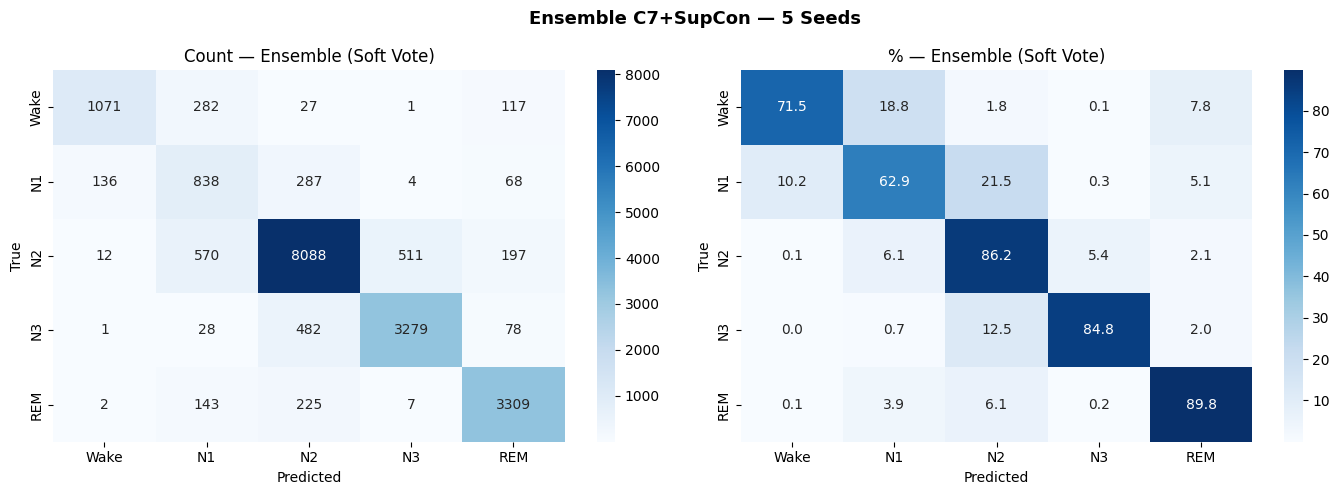

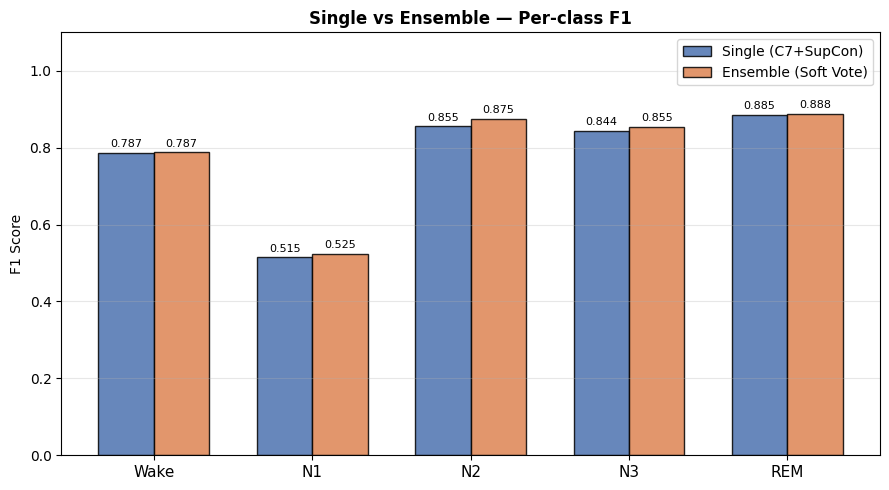


Outputs saved: D:\22\AA\evaluation\ensemble_n1aug_c7_supcon
Done!


In [2]:



# ============================================================
# Ensemble Evaluation — C7 + SupCon (best 5 seeds)
#
# তোমার 5টা best_seed*.pt checkpoint লোড করে
# soft voting (probability average) দিয়ে ensemble করে।
#
# কোনো training নেই — শুধু inference।
# 5 মিনিটেই শেষ।
# ============================================================

import os
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS — তোমার best model folder এর path দাও
# ============================================================
SAVE_PATH      = r"D:\22\AA\preprocess\preprocessed_FFinal"
ARTIFACT_PATH  = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"

# ★ এই path এ তোমার 5টা best_seed*.pt আছে
CHECKPOINT_DIR = r"D:\22\AA\evaluation\supcon_c7_n1aug_artifact-aware"

EVAL_PATH      = r"D:\22\AA\evaluation\ensemble_n1aug_c7_supcon"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

# SupCon config (same as training)
SUPCON_TEMP = 0.05
PROJ_DIM    = 64
D_MODEL     = 128
NHEAD       = 8
NUM_LAYERS  = 3
DIM_FF      = 256
DROPOUT     = 0.4

ARTIFACT_WEIGHT_MAP = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_CHANNELS     = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_CHANNELS   = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device         : {device}")
print(f"Checkpoint dir : {CHECKPOINT_DIR}")
print(f"Output         : {EVAL_PATH}")


# ============================================================
# ARTIFACT WEIGHT LOADER
# ============================================================
def load_artifact_weights(subject_id, artifact_path, epoch_duration=30):
    tsv_path = os.path.join(
        artifact_path, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return None
    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return None

    available = [ch for ch in TARGET_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_CHANNELS if ch in df.columns]
    if not available:
        return None

    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // epoch_duration).astype(int)
    epoch_scores = df.groupby('sleep_epoch')['worst_score'].max()

    n_ep    = int(epoch_scores.index.max()) + 1
    weights = np.ones(n_ep, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        weights[int(ep_idx)] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)
    return weights


# ============================================================
# FIXED SPLIT — same test set
# ============================================================
_test_path = os.path.join(SAVE_PATH, "_test_subs.npy")
TEST_SUBS  = np.load(_test_path, allow_pickle=True).tolist()
print(f"Test subjects  : {len(TEST_SUBS)}")
print(f"TEST_SUBS: {TEST_SUBS}")


# ============================================================
# DATASET
# ============================================================
class ArtifactAwareDataset(Dataset):
    def __init__(self, subject_list, data_path,
                 artifact_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],    :]
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d['labels'].copy()

            n     = len(labels)
            art_w = load_artifact_weights(sub, artifact_path)
            if art_w is None:
                art_w = np.ones(n, dtype=np.float32)
            else:
                if len(art_w) >= n:
                    art_w = art_w[:n]
                else:
                    art_w = np.concatenate([art_w, np.ones(n - len(art_w), dtype=np.float32)])

            sub_idx = len(self.data)
            self.data.append((signal, labels))
            for i in range(n):
                self.index.append((sub_idx, i, n, float(art_w[i])))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])

        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])
        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32)
        )


print("\nLoading test dataset...")
test_ds = ArtifactAwareDataset(TEST_SUBS, SAVE_PATH, ARTIFACT_PATH)
print(f"Test samples: {len(test_ds):,}")

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0
)


# ============================================================
# MODEL — same as C7 SupCon training
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class ContextCNNTransformerSupCon(nn.Module):
    def __init__(
        self, in_ch=3, d_model=D_MODEL, nhead=NHEAD,
        num_layers=NUM_LAYERS, dim_ff=DIM_FF, dropout=DROPOUT,
        n_classes=5, context=CONTEXT, proj_dim=PROJ_DIM
    ):
        super().__init__()
        self.context = context
        self.d_model  = d_model

        self.epoch_cnn = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=50, stride=6, padding=25),
            nn.BatchNorm1d(32), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(32, 64, kernel_size=8, padding=4),
            nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            intra_seq = self.epoch_cnn(torch.zeros(1, in_ch, 3000)).shape[2]

        self.intra_pos = PositionalEncoding(d_model, max_len=intra_seq + 10, dropout=dropout)
        self.intra_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=1
        )
        self.inter_pos = PositionalEncoding(d_model, max_len=WINDOW + 2, dropout=dropout)
        self.inter_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=num_layers
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )
        self.projector = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        feat = self.epoch_cnn(x.view(B * W, C, T)).permute(0, 2, 1)
        feat = self.intra_transformer(self.intra_pos(feat)).mean(dim=1).view(B, W, self.d_model)
        feat = self.inter_transformer(self.inter_pos(feat))
        center = feat[:, self.context, :]
        logits = self.classifier(center)
        proj   = F.normalize(self.projector(center), dim=1)
        return logits, proj


# ============================================================
# LOAD ALL 5 MODELS
# ============================================================
print(f"\nLoading 5 checkpoints from:\n  {CHECKPOINT_DIR}")
models = []
for seed in SEEDS:
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_seed{seed}.pt")
    if not os.path.exists(ckpt_path):
        print(f"  ✗ NOT FOUND: best_seed{seed}.pt")
        continue
    m = ContextCNNTransformerSupCon(in_ch=3).to(device)
    m.load_state_dict(torch.load(ckpt_path, map_location=device))
    m.eval()
    models.append((seed, m))
    print(f"  ✓ Loaded: best_seed{seed}.pt")

print(f"\nEnsemble size: {len(models)} models")


# ============================================================
# ENSEMBLE INFERENCE — Soft Voting
#
# প্রতিটা model এর softmax probability average করো
# তারপর argmax নাও
# ============================================================
print("\nRunning ensemble inference...")

all_probs   = []   # (N_models, N_samples, 5)
all_labels  = []
all_weights = []

# প্রথমে labels আর weights collect করো
with torch.no_grad():
    for x, y, w in test_loader:
        all_labels.extend(y.numpy())
        all_weights.extend(w.numpy())

all_labels  = np.array(all_labels)
all_weights = np.array(all_weights)

# প্রতিটা model এর probability collect করো
for seed, model in models:
    model_probs = []
    with torch.no_grad():
        for x, y, w in test_loader:
            logits, _ = model(x.to(device))
            probs = F.softmax(logits, dim=1).cpu().numpy()
            model_probs.append(probs)
    model_probs = np.concatenate(model_probs, axis=0)   # (N, 5)
    all_probs.append(model_probs)
    print(f"  Model seed={seed} done")

# Stack: (N_models, N, 5)
all_probs = np.stack(all_probs, axis=0)

# Soft voting: average probabilities
ensemble_probs = all_probs.mean(axis=0)   # (N, 5)
ensemble_preds = ensemble_probs.argmax(axis=1)

# ============================================================
# METRICS
# ============================================================
acc     = accuracy_score(all_labels, ensemble_preds)
f1      = f1_score(all_labels, ensemble_preds, average='macro', zero_division=0)
kappa   = cohen_kappa_score(all_labels, ensemble_preds)
per_cls = f1_score(all_labels, ensemble_preds, average=None, zero_division=0)

clean_mask = all_weights == 1.0
noisy_mask = (all_weights > 0) & (all_weights < 1.0)
clean_acc  = accuracy_score(all_labels[clean_mask], ensemble_preds[clean_mask])
noisy_acc  = accuracy_score(all_labels[noisy_mask], ensemble_preds[noisy_mask])

print(f"\n{'='*55}")
print(f"ENSEMBLE RESULT ({len(models)} models, soft voting)")
print(f"{'='*55}")
print(f"  Accuracy      : {acc*100:.2f}%")
print(f"  Macro F1      : {f1:.4f}")
print(f"  Cohen Kappa   : {kappa:.4f}")
print(f"  Clean Acc     : {clean_acc*100:.2f}% ({clean_mask.sum()} epochs)")
print(f"  Noisy Acc     : {noisy_acc*100:.2f}% ({noisy_mask.sum()} epochs)")
print(f"  {'-'*53}")
print("  Per-class F1:")
for i, name in enumerate(LABEL_NAMES):
    bar = chr(9608) * int(per_cls[i] * 16)
    print(f"    {name:6s}: {per_cls[i]:.4f}  {bar}")
print(f"{'='*55}")

# ============================================================
# COMPARE: Single best vs Ensemble
# ============================================================
print(f"\n{'='*55}")
print("COMPARISON: Single Best vs Ensemble")
print(f"{'='*55}")
print(f"{'Model':<35} {'Acc%':>7} {'F1':>7} {'N1':>7}")
print("-" * 55)
print(f"{'C7+SupCon λ=0.2 (single best)':<35} {'82.31':>7} {'0.7772':>7} {'0.5146':>7}")
print(f"{'Ensemble (5 seeds, soft vote)':<35} {acc*100:>7.2f} {f1:>7.4f} {per_cls[1]:>7.4f}")
print(f"{'='*55}")


val_f1_scores = {42: 0.7664, 123: 0.7644, 256: 0.7662, 789: 0.7696, 999: 0.7787}

seed_order    = [s for s, _ in models]
weights_w     = np.array([val_f1_scores[s] for s in seed_order])
weights_w     = weights_w / weights_w.sum()   # normalize

print(f"\nWeighted ensemble weights:")
for s, w in zip(seed_order, weights_w):
    print(f"  seed={s}: {w:.4f}")

weighted_probs = np.sum(
    all_probs * weights_w[:, np.newaxis, np.newaxis], axis=0
)
weighted_preds = weighted_probs.argmax(axis=1)

acc_w     = accuracy_score(all_labels, weighted_preds)
f1_w      = f1_score(all_labels, weighted_preds, average='macro', zero_division=0)
kappa_w   = cohen_kappa_score(all_labels, weighted_preds)
per_cls_w = f1_score(all_labels, weighted_preds, average=None, zero_division=0)

print(f"\n{'='*55}")
print("WEIGHTED ENSEMBLE RESULT")
print(f"{'='*55}")
print(f"  Accuracy    : {acc_w*100:.2f}%")
print(f"  Macro F1    : {f1_w:.4f}")
print(f"  Cohen Kappa : {kappa_w:.4f}")
print("  Per-class F1:")
for i, name in enumerate(LABEL_NAMES):
    bar = chr(9608) * int(per_cls_w[i] * 16)
    print(f"    {name:6s}: {per_cls_w[i]:.4f}  {bar}")
print(f"{'='*55}")

# ============================================================
# FINAL SUMMARY TABLE
# ============================================================
print(f"\n{'='*55}")
print("FINAL COMPARISON TABLE")
print(f"{'='*55}")
print(f"{'Model':<35} {'Acc%':>7} {'F1':>7} {'N1 F1':>7}")
print("-" * 55)
print(f"{'C7+SupCon (single, λ=0.2)':<35} {'82.31':>7} {'0.7772':>7} {'0.5146':>7}")
print(f"{'Ensemble soft vote':<35} {acc*100:>7.2f} {f1:>7.4f} {per_cls[1]:>7.4f}")
print(f"{'Ensemble weighted vote':<35} {acc_w*100:>7.2f} {f1_w:>7.4f} {per_cls_w[1]:>7.4f}")
print(f"{'='*55}")

# ============================================================
# CONFUSION MATRIX — best ensemble
# ============================================================
best_preds  = ensemble_preds if f1 >= f1_w else weighted_preds
best_name   = "Soft Vote" if f1 >= f1_w else "Weighted Vote"

cm     = confusion_matrix(all_labels, best_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title(f"Count — Ensemble ({best_name})")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title(f"% — Ensemble ({best_name})")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

fig.suptitle(f"Ensemble C7+SupCon — {len(models)} Seeds",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_ensemble.png"), dpi=150)
plt.show()

# Per-class F1 comparison bar
fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(5)
width = 0.35
colors_single   = ['#4C72B0'] * 5
colors_ensemble = ['#DD8452'] * 5

single_f1 = [0.7867, 0.5146, 0.8554, 0.8442, 0.8850]  # from best single model

bars1 = ax.bar(x - width/2, single_f1,  width, label='Single (C7+SupCon)',
               color=colors_single,   edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, per_cls_w if f1_w >= f1 else per_cls,
               width, label=f'Ensemble ({best_name})',
               color=colors_ensemble, edgecolor='black', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.1)
ax.set_title("Single vs Ensemble — Per-class F1", fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "perclass_f1_single_vs_ensemble.png"), dpi=150)
plt.show()

print(f"\nOutputs saved: {EVAL_PATH}")
print("Done!")

In [1]:
print("hi")

hi
